# **For Small Dataset**

**SVM**

Accuracy: 0.9689

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97      2264
           1       0.95      0.97      0.96      1462

    accuracy                           0.97      3726
   macro avg       0.97      0.97      0.97      3726
weighted avg       0.97      0.97      0.97      3726



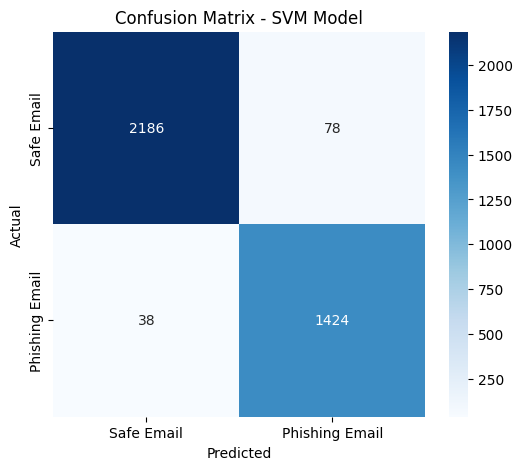


Prediction: Safe Email


In [4]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load Dataset
data = pd.read_csv('/content/drive/MyDrive/Dataset/Phishing_Email.csv')
data = data[['Email Text', 'Email Type']]
data.columns = ['message', 'label']
data.dropna(inplace=True)
data['message'] = data['message'].astype(str)

# 2. Clean Text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', ' url ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['message'] = data['message'].apply(clean_text)
data = data[data['message'].str.len() > 3]

# 3. Label Encoding
data['label'] = data['label'].str.lower().map({
    'safe email': 0,
    'phishing email': 1
})
data.dropna(inplace=True)
data['label'] = data['label'].astype(int)

# 4. TF-IDF
vectorizer = TfidfVectorizer(
    token_pattern=r'(?u)\b[a-z]{2,}\b',
    min_df=2,
    max_features=3000
)
X = vectorizer.fit_transform(data['message'])
y = data['label']

# 5. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Train SVM
model = LinearSVC(max_iter=3000)
model.fit(X_train, y_train)

# 7. Evaluation & Confusion Matrix
y_pred = model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe Email', 'Phishing Email'],
            yticklabels=['Safe Email', 'Phishing Email'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM Model')
plt.show()

#test_email = ["Congratulations! Your bank account has been suspended. Click here to verify immediately."]
test_email = ["Hi Team, attached is the report for this month's meeting. Let me know if you have any questions. Thanks, John."]

test_clean = [clean_text(test_email[0])]

prediction = model.predict(vectorizer.transform(test_clean))

print("\nPrediction:",
      "Phishing Email" if prediction[0] == 1 else "Safe Email")

**Random Forest**

Accuracy: 0.9656468062265163

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97      2264
           1       0.95      0.97      0.96      1462

    accuracy                           0.97      3726
   macro avg       0.96      0.97      0.96      3726
weighted avg       0.97      0.97      0.97      3726



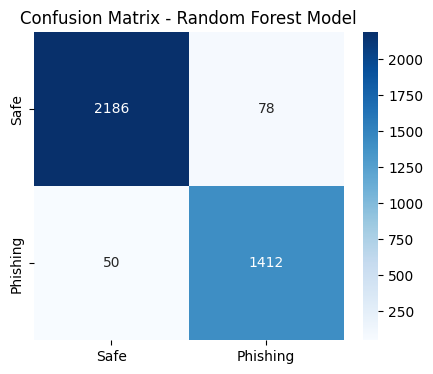


Prediction: Phishing Email


In [5]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# 2. Load Dataset


data = pd.read_csv("/content/drive/MyDrive/Dataset/Phishing_Email.csv")

data = data[['Email Text', 'Email Type']]
data.columns = ['message', 'label']

data.dropna(inplace=True);
data['message'] = data['message'].astype(str)


# 3. Cleaning


def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", " url ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

data['message'] = data['message'].apply(clean_text)
data = data[data['message'].str.len() > 3]

data['label'] = data['label'].str.lower().map({
    'safe email': 0,
    'phishing email': 1
})

data.dropna(inplace=True);
data['label'] = data['label'].astype(int)


# 4. Improved TF-IDF


vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=8000,
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

X = vectorizer.fit_transform(data['message'])
y = data['label']


# 5. Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 6. Fast + Accurate Model (Random Forest)


model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

model.fit(X_train, y_train)


# 7. Evaluation


y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe', 'Phishing'],
            yticklabels=['Safe', 'Phishing'])
plt.title("Confusion Matrix - Random Forest Model")
plt.show()

test_email = ["Congratulations! Your bank account has been suspended. Click here to verify immediately."]
# test_email = ["Hi Team, attached is the report for this month's meeting. Let me know if you have any questions. Thanks, John."]

test_clean = [clean_text(test_email[0])]

prediction = model.predict(vectorizer.transform(test_clean))

print("\nPrediction:",
      "Phishing Email" if prediction[0] == 1 else "Safe Email")

# **For Large Dataset**

**LinearSVC**

Training ultra-fast model...

🔥 Accuracy: 97.81%

              precision    recall  f1-score   support

         Ham       0.98      0.97      0.98     20432
        Spam       0.97      0.98      0.98     18339

    accuracy                           0.98     38771
   macro avg       0.98      0.98      0.98     38771
weighted avg       0.98      0.98      0.98     38771



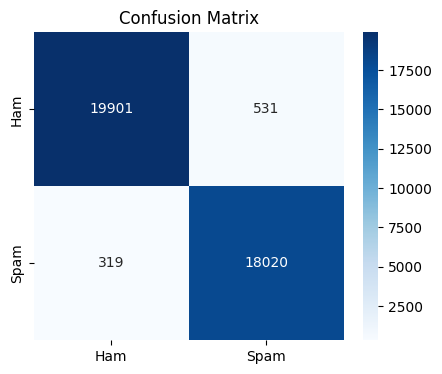


===== Testing =====

📧 URGENT!!! Your account suspended $$$
➡️ Spam (77.61%)

📧 Hi Yash meeting at 4 PM
➡️ Ham (14.55%)

📧 WINNER free iPhone now
➡️ Spam (80.66%)

📧 Project report attached
➡️ Ham (6.90%)

📧 You Won Money
➡️ Spam (79.05%)


In [6]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ===============================
# 1. Load Data
# ===============================
df = pd.read_csv('/content/drive/MyDrive/Dataset/spam_emails_data.csv', usecols=['text', 'label'])
df['text'] = df['text'].fillna('')

# ===============================
# 2. Meta Features (FAST)
# ===============================
caps = df['text'].str.count(r'[A-Z]')
length = df['text'].str.len().replace(0, 1)

meta_features = csr_matrix(np.vstack([
    caps / length,
    df['text'].str.count(r'!'),
    df['text'].str.count(r'\$')
]).T)

# ===============================
# 3. Fast Cleaning
# ===============================
pattern = re.compile(r'[^a-z\s]')
cleaned_text = df['text'].str.lower().str.replace(pattern, '', regex=True)

# ===============================
# 4. TF-IDF (More Optimized)
# ===============================
vectorizer = TfidfVectorizer(
    max_features=7000,      # further reduced
    stop_words='english',
    ngram_range=(1,1),      # remove bigrams (BIG speed boost)
    min_df=10               # fewer features
)

tfidf_features = vectorizer.fit_transform(cleaned_text)

# ===============================
# 5. Combine
# ===============================
X = hstack([tfidf_features, meta_features])

X_train, X_test, y_train, y_test = train_test_split(
    X, df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# ===============================
# 6. ULTRA FAST MODEL
# ===============================
model = LinearSVC(
    dual=False,
    class_weight='balanced',
    random_state=42
)

print("Training ultra-fast model...")
model.fit(X_train, y_train)

# ===============================
# 7. Results
# ===============================
y_pred = model.predict(X_test)

print(f"\n🔥 Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%\n")
print(classification_report(y_test, y_pred))

# ===============================
# 8. Confusion Matrix
# ===============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.show()

# ===============================
# 9. FAST Testing
# ===============================
print("\n===== Testing =====")

sample_emails = [
    "URGENT!!! Your account suspended $$$",
    "Hi Yash meeting at 4 PM",
    "WINNER free iPhone now",
    "Project report attached",
    "You Won Money"
]

def process_new(emails):
    s = pd.Series(emails)

    meta = csr_matrix(np.vstack([
        s.str.count(r'[A-Z]') / s.str.len().replace(0,1),
        s.str.count(r'!'),
        s.str.count(r'\$')
    ]).T)

    clean = s.str.lower().str.replace(pattern, '', regex=True)
    tfidf = vectorizer.transform(clean)

    return hstack([tfidf, meta])

X_samples = process_new(sample_emails)

preds = model.predict(X_samples)

# 🔥 Fast confidence approximation
decision = model.decision_function(X_samples)
confidence = 1 / (1 + np.exp(-decision))  # sigmoid

for email, pred, conf in zip(sample_emails, preds, confidence):
    print(f"\n📧 {email}")
    print(f"➡️ {pred} ({conf*100:.2f}%)")

**LinearSVC + CalibratedClassifierCV Hybrid**

Extracting meta-features...
Cleaning text and building TF-IDF...
Training LinearSVC Hybrid Model...
Overall Accuracy: 98.27%

              precision    recall  f1-score   support

         Ham       0.99      0.98      0.98     20432
        Spam       0.98      0.98      0.98     18339

    accuracy                           0.98     38771
   macro avg       0.98      0.98      0.98     38771
weighted avg       0.98      0.98      0.98     38771



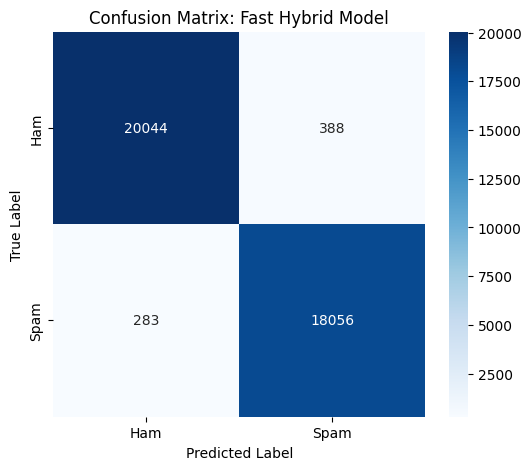


===== Testing on New Emails =====

Email: URGENT!!! Your account has been suspended. Click here to rea...
Result: Spam (99.48% confidence)

Email: Hi Yash, can we reschedule our meeting to 4 PM?...
Result: Ham (93.58% confidence)

Email: WINNER! You've won a free iPhone! Claim your prize here now...
Result: Spam (98.90% confidence)

Email: Please find attached the latest project report....
Result: Ham (100.00% confidence)

Email: Your Amazon account is on hold. Verify your identity immedia...
Result: Spam (99.98% confidence)

Email: You Won Money...
Result: Spam (98.81% confidence)


In [7]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ===============================
# 1. Load Data
# ===============================
df = pd.read_csv('/content/drive/MyDrive/Dataset/spam_emails_data.csv', usecols=['text', 'label'])
df['text'] = df['text'].fillna('') # Handle missing values instantly

# ===============================
# 2. Extract "Meta-Features" (Before cleaning!)
# ===============================
# Spammers use ALL CAPS, exclamation marks, and money symbols.
# We capture these as raw numerical features before they get erased.
print("Extracting meta-features...")
def extract_meta_features(text_series):
    caps_count = text_series.str.count(r'[A-Z]')
    length = text_series.str.len().replace(0, 1) # Avoid division by zero

    features = pd.DataFrame({
        'caps_ratio': caps_count / length,
        'exclamation_count': text_series.str.count(r'!'),
        'dollar_count': text_series.str.count(r'\$')
    })
    return csr_matrix(features.values) # Convert to sparse matrix for speed

meta_features = extract_meta_features(df['text'])

# ===============================
# 3. Fast Clean & TF-IDF
# ===============================
def fast_clean_corpus(corpus):
    pattern = re.compile(r'[^a-z\s]')
    return [pattern.sub('', str(text).lower()) for text in corpus]

print("Cleaning text and building TF-IDF...")
cleaned_text = fast_clean_corpus(df['text'])

vectorizer = TfidfVectorizer(
    max_features=15000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=3
)
tfidf_features = vectorizer.fit_transform(cleaned_text)

# ===============================
# 4. Combine Features & Split
# ===============================
# Combine word features (TF-IDF) + structural features (Meta)
X_combined = hstack([tfidf_features, meta_features])

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# ===============================
# 5. The Ultimate Fast Model: LinearSVC
# ===============================
# LinearSVC is the fastest algorithm for sparse text matrices.
# We wrap it in CalibratedClassifierCV just so we can get percentage confidences later.
base_svc = LinearSVC(dual=False, class_weight='balanced', random_state=42)
model = CalibratedClassifierCV(estimator=base_svc, cv=3)

print("Training LinearSVC Hybrid Model...")
model.fit(X_train, y_train)

# ===============================
# 6. Results & Confusion Matrix
# ===============================
y_pred = model.predict(X_test)
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred))

# Plotting the Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Confusion Matrix: Fast Hybrid Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ===============================
# 7. Custom Testing Pipeline
# ===============================
print("\n===== Testing on New Emails =====")
sample_emails = [
    "URGENT!!! Your account has been suspended. Click here to reactivate now $$$",
    "Hi Yash, can we reschedule our meeting to 4 PM?",
    "WINNER! You've won a free iPhone! Claim your prize here now",
    "Please find attached the latest project report.",
    "Your Amazon account is on hold. Verify your identity immediately.",
    "You Won Money"
]

# Create a helper function to process new emails exactly like the training data
def process_new_emails(emails):
    email_series = pd.Series(emails)
    new_meta = extract_meta_features(email_series)
    new_cleaned = fast_clean_corpus(emails)
    new_tfidf = vectorizer.transform(new_cleaned)
    return hstack([new_tfidf, new_meta])

X_samples = process_new_emails(sample_emails)
preds = model.predict(X_samples)
probs = model.predict_proba(X_samples)

for email, pred, prob in zip(sample_emails, preds, probs):
    label = str(pred).capitalize()
    confidence = max(prob) * 100
    print(f"\nEmail: {email[:60]}...")
    print(f"Result: {label} ({confidence:.2f}% confidence)")